# Рубежный контроль 1 по дисциплине Методы машинного обучения в автоматизированных системах

**Задания:**
- **Задача №2:** Target (mean) encoding категориального признака
- **Задача №22:** Масштабирование числового признака по максимальному значению
- **Доп. задание:** Ящик с усами (box plot)

## Импорт библиотек и создание набора данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MaxAbsScaler

np.random.seed(42)

In [3]:
n = 250

platform_params = {
    'Coursera':  {'mean': 49.0,  'std': 15.0},
    'Udemy':     {'mean': 14.99, 'std':  6.0},
    'edX':       {'mean': 75.0,  'std': 20.0},
    'Skillbox':  {'mean': 120.0, 'std': 30.0},
    'Stepik':    {'mean': 12.0,  'std':  5.0},
}
platforms = list(platform_params.keys())
platform_col = np.random.choice(platforms, size=n, p=[0.25, 0.25, 0.15, 0.15, 0.20])

price_col = np.array([
    np.random.normal(platform_params[p]['mean'], platform_params[p]['std'])
    for p in platform_col
]).clip(0, 500)

df = pd.DataFrame({
    'platform':        platform_col,
    'num_lectures':    np.random.randint(10, 300, size=n),
    'duration_hours':  np.round(np.random.uniform(1.0, 80.0, size=n), 1),
    'num_reviews':     np.random.randint(10, 50000, size=n),
    'rating':          np.round(np.random.uniform(3.0, 5.0, size=n), 1),
    'year_published':  np.random.randint(2015, 2024, size=n),
    'category':        np.random.choice(
                           ['Data Science', 'Web Development', 'Business', 'Design', 'Marketing'],
                           size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
    'level':           np.random.choice(['Beginner', 'Intermediate', 'Advanced'], size=n,
                                         p=[0.40, 0.40, 0.20]),
    'price_usd':       price_col.round(2),
})

print(f'Датасет создан: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(10)

Датасет создан: 250 строк, 9 столбцов


,platform,num_lectures,duration_hours,num_reviews,rating,year_published,category,level,price_usd
0,Coursera,222,7.1,48705,4.0,2019,Business,Intermediate,55.84
1,Coursera,225,43.9,44462,3.4,2023,Marketing,Advanced,81.48
2,Coursera,235,69.1,43418,3.9,2019,Business,Beginner,39.35
3,edX,140,47.6,32451,4.8,2016,Web Development,Intermediate,93.56
4,edX,85,18.9,41440,3.4,2018,Marketing,Intermediate,76.14
5,edX,295,31.4,39139,3.4,2023,Data Science,Intermediate,80.37
6,Coursera,286,36.6,34726,3.0,2015,Design,Beginner,71.93
7,Udemy,165,46.8,44869,3.0,2015,Marketing,Intermediate,18.04
8,edX,257,61.0,26596,4.7,2021,Design,Beginner,85.77
9,Udemy,227,8.8,44770,4.5,2017,Business,Advanced,21.43


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   platform        250 non-null    object 
 1   num_lectures    250 non-null    int32  
 2   duration_hours  250 non-null    float64
 3   num_reviews     250 non-null    int32  
 4   rating          250 non-null    float64
 5   year_published  250 non-null    int32  
 6   category        250 non-null    object 
 7   level           250 non-null    object 
 8   price_usd       250 non-null    float64
dtypes: float64(3), int32(3), object(3)
memory usage: 14.8+ KB


In [5]:
df.describe()

,num_lectures,duration_hours,num_reviews,rating,year_published,price_usd
count,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,160.80800,40.352800,26799.616000,4.004800,2018.764000,51.038720
std,82.74912,23.029299,13808.528145,0.596018,2.635162,40.974163
min,10.00000,1.200000,502.000000,3.000000,2015.000000,0.000000
25%,92.25000,19.700000,15470.000000,3.500000,2016.000000,16.025000
50%,158.50000,42.100000,27164.500000,4.000000,2019.000000,43.220000
75%,230.25000,59.675000,39137.000000,4.600000,2021.000000,75.830000
max,298.00000,80.000000,49439.000000,5.000000,2023.000000,198.050000


---
## Задача №2 — Target (Mean) Encoding категориального признака

**Target encoding** (среднее по целевой переменной) заменяет каждую категорию числом — средним значением целевой переменной (`price_usd`) внутри этой категории.

**Выбранный признак:** `platform` (платформа онлайн-курса)  
**Целевая переменная:** `price_usd` (цена курса в USD)

In [6]:
target_col = 'price_usd'
cat_col    = 'platform'

mean_target_by_platform = df.groupby(cat_col)[target_col].mean()

print('Среднее значение price_usd по каждой платформе:')
print(mean_target_by_platform.sort_values(ascending=False).round(2))

Среднее значение price_usd по каждой платформе:
platform
Skillbox    117.08
edX          82.44
Coursera     49.78
Udemy        16.75
Stepik       11.82
Name: price_usd, dtype: float64


In [7]:
df['platform_target_enc'] = df[cat_col].map(mean_target_by_platform)

print('Результат target encoding:')
df[['platform', 'price_usd', 'platform_target_enc']].head(15)

Результат target encoding:


,platform,price_usd,platform_target_enc
0,Coursera,55.84,49.782817
1,Coursera,81.48,49.782817
2,Coursera,39.35,49.782817
3,edX,93.56,82.444054
4,edX,76.14,82.444054
5,edX,80.37,82.444054
6,Coursera,71.93,49.782817
7,Udemy,18.04,16.748103
8,edX,85.77,82.444054
9,Udemy,21.43,16.748103


In [8]:
summary_te = (
    df.groupby('platform')
      .agg(
          count          = ('price_usd', 'count'),
          mean_price_usd = ('price_usd', 'mean'),
          target_enc_val = ('platform_target_enc', 'first')
      )
      .round(2)
      .sort_values('mean_price_usd', ascending=False)
)
print('Сводная таблица target encoding:')
summary_te

Сводная таблица target encoding:


,count,mean_price_usd,target_enc_val
platform,,,
Skillbox,40,117.08,117.08
edX,37,82.44,82.44
Coursera,71,49.78,49.78
Udemy,58,16.75,16.75
Stepik,44,11.82,11.82


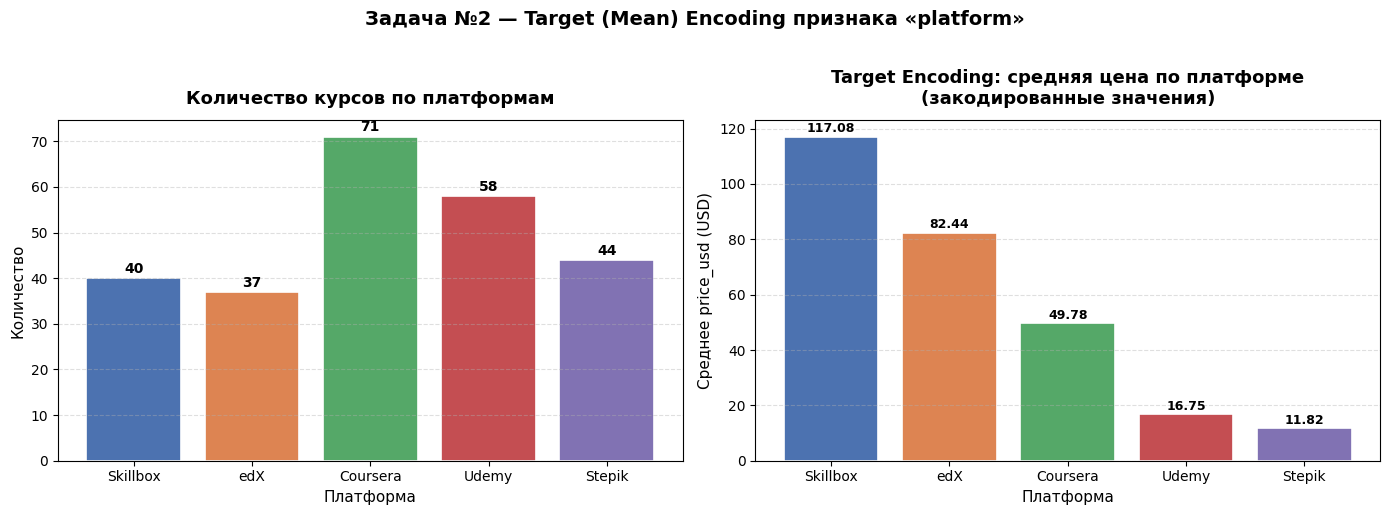


Вывод: категориальный признак «platform» заменён средним значением цены (price_usd)
для каждой категории. Метод позволяет сохранить информацию о целевой переменной.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

platforms_sorted = summary_te.index.tolist()
enc_values       = summary_te['target_enc_val'].tolist()
counts           = summary_te['count'].tolist()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

# --- График 1: Кол-во курсов по платформам ---
bars = axes[0].bar(platforms_sorted, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Количество курсов по платформам', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Платформа', fontsize=11)
axes[0].set_ylabel('Количество', fontsize=11)
axes[0].grid(axis='y', alpha=0.4, linestyle='--')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- График 2: Target Encoded значения ---
bars2 = axes[1].bar(platforms_sorted, enc_values, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Target Encoding: средняя цена по платформе\n(закодированные значения)',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Платформа', fontsize=11)
axes[1].set_ylabel('Среднее price_usd (USD)', fontsize=11)
axes[1].grid(axis='y', alpha=0.4, linestyle='--')
for bar, val in zip(bars2, enc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Задача №2 — Target (Mean) Encoding признака «platform»',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nВывод: категориальный признак «platform» заменён средним значением цены (price_usd)')
print('для каждой категории. Метод позволяет сохранить информацию о целевой переменной.')

---
## Задача №22 — Масштабирование по максимальному значению (Max Scaling)

**Max Scaling** (масштабирование по максимуму) делит каждое значение признака на **максимальное абсолютное значение** в столбце, приводя данные к диапазону **[-1, 1]** (или [0, 1] для неотрицательных признаков).

$$x_{scaled} = \dfrac{x}{\max(|x|)}$$

**Выбранный признак:** `num_reviews` (количество отзывов на курс)

In [10]:
num_col = 'num_reviews'

print('=== Статистики ДО масштабирования ===')
print(df[num_col].describe().round(2))
print(f'\nМаксимальное значение: {df[num_col].max()}')

=== Статистики ДО масштабирования ===
count      250.00
mean     26799.62
std      13808.53
min        502.00
25%      15470.00
50%      27164.50
75%      39137.00
max      49439.00
Name: num_reviews, dtype: float64

Максимальное значение: 49439


In [11]:
scaler = MaxAbsScaler()

reviews_values = df[[num_col]].values
reviews_scaled = scaler.fit_transform(reviews_values)

df['num_reviews_maxscaled'] = reviews_scaled

print('=== Статистики ПОСЛЕ масштабирования ===')
print(df['num_reviews_maxscaled'].describe().round(6))
print(f'\nМасштабирующий множитель (max abs value): {scaler.max_abs_[0]:.0f}')

=== Статистики ПОСЛЕ масштабирования ===
count    250.000000
mean       0.542074
std        0.279304
min        0.010154
25%        0.312911
50%        0.549455
75%        0.791622
max        1.000000
Name: num_reviews_maxscaled, dtype: float64

Масштабирующий множитель (max abs value): 49439


In [12]:
max_abs_val = df[num_col].abs().max()
df['num_reviews_manual'] = df[num_col] / max_abs_val

match = np.allclose(df['num_reviews_maxscaled'], df['num_reviews_manual'])
print(f'Результаты sklearn и ручного вычисления совпадают: {match}')

print('\nПервые 10 строк — сравнение исходных и масштабированных значений:')
df[['num_reviews', 'num_reviews_maxscaled']].head(10)

Результаты sklearn и ручного вычисления совпадают: True

Первые 10 строк — сравнение исходных и масштабированных значений:


,num_reviews,num_reviews_maxscaled
0,48705,0.985153
1,44462,0.899330
2,43418,0.878214
3,32451,0.656385
4,41440,0.838205
5,39139,0.791662
6,34726,0.702401
7,44869,0.907563
8,26596,0.537956
9,44770,0.905560


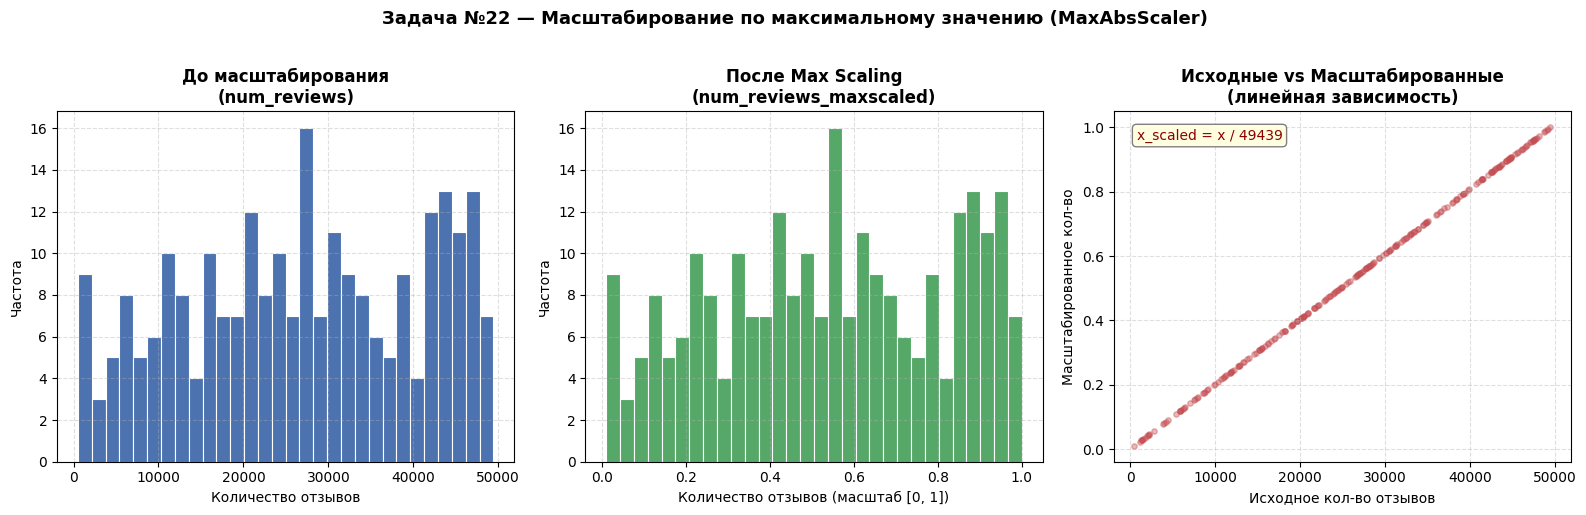

Вывод: признак «num_reviews» приведён к диапазону [0, 1] путём деления
каждого значения на максимальное абсолютное значение (49439 отзывов).


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Гистограмма до
axes[0].hist(df['num_reviews'], bins=30, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0].set_title('До масштабирования\n(num_reviews)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество отзывов', fontsize=10)
axes[0].set_ylabel('Частота', fontsize=10)
axes[0].grid(alpha=0.4, linestyle='--')

# Гистограмма после
axes[1].hist(df['num_reviews_maxscaled'], bins=30, color='#55A868', edgecolor='white', linewidth=0.8)
axes[1].set_title('После Max Scaling\n(num_reviews_maxscaled)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Количество отзывов (масштаб [0, 1])', fontsize=10)
axes[1].set_ylabel('Частота', fontsize=10)
axes[1].grid(alpha=0.4, linestyle='--')

# Scatter: исходные vs масштабированные
axes[2].scatter(df['num_reviews'], df['num_reviews_maxscaled'],
                alpha=0.4, s=15, color='#C44E52')
axes[2].set_title('Исходные vs Масштабированные\n(линейная зависимость)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Исходное кол-во отзывов', fontsize=10)
axes[2].set_ylabel('Масштабированное кол-во', fontsize=10)
axes[2].grid(alpha=0.4, linestyle='--')

formula = f'x_scaled = x / {max_abs_val:.0f}'
axes[2].annotate(formula, xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=10, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

plt.suptitle('Задача №22 — Масштабирование по максимальному значению (MaxAbsScaler)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Вывод: признак «num_reviews» приведён к диапазону [0, 1] путём деления')
print(f'каждого значения на максимальное абсолютное значение ({max_abs_val:.0f} отзывов).')

---
## Дополнительное задание — Ящик с усами (Box Plot)

**Ящик с усами (Box Plot)** — диаграмма, которая отображает пять ключевых статистик:
- **Медиана (Q2)** — центральная линия внутри прямоугольника
- **Q1 и Q3** — нижняя и верхняя границы прямоугольника (межквартильный размах, IQR)
- **Усы** — простираются до 1.5 × IQR от границ ящика
- **Выбросы** — точки за пределами усов

**Визуализируем:** распределение `duration_hours` (продолжительность курса в часах) по платформам.

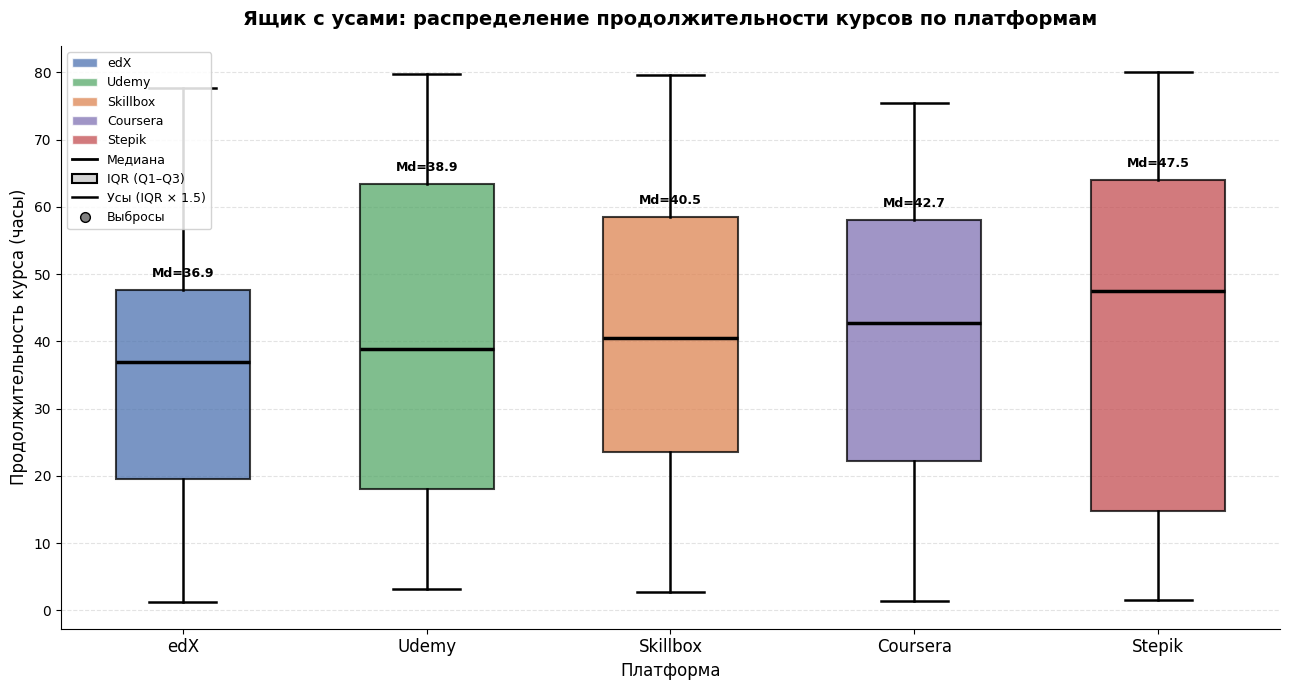

Вывод: ящик с усами показывает распределение продолжительности курсов
для каждой платформы — медиану, межквартильный размах, разброс и выбросы.


In [14]:
platform_order = df.groupby('platform')['duration_hours'].median().sort_values().index.tolist()
data_by_platform = [df[df['platform'] == p]['duration_hours'].values for p in platform_order]

palette = ['#4C72B0', '#55A868', '#DD8452', '#8172B3', '#C44E52']

fig, ax = plt.subplots(figsize=(13, 7))

bp = ax.boxplot(
    data_by_platform,
    positions=range(1, len(platform_order) + 1),
    patch_artist=True,
    widths=0.55,
    showfliers=True,
    medianprops=dict(linewidth=2.5),
    whiskerprops=dict(linewidth=1.8),
    capprops=dict(linewidth=1.8),
    boxprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, linestyle='none', alpha=0.6)
)

# Раскрашиваем ящики и выбросы
for i, (patch, color) in enumerate(zip(bp['boxes'], palette)):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, (flier, color) in enumerate(zip(bp['fliers'], palette)):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor('black')
    flier.set_markeredgewidth(0.5)

for median_line, color in zip(bp['medians'], palette):
    median_line.set_color('black')

# Аннотации: медиана над каждым ящиком
for i, data in enumerate(data_by_platform):
    med = np.median(data)
    q3  = np.percentile(data, 75)
    ax.text(i + 1, q3 + 1.5, f'Md={med:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

ax.set_xticks(range(1, len(platform_order) + 1))
ax.set_xticklabels(platform_order, fontsize=12)
ax.set_xlabel('Платформа', fontsize=12)
ax.set_ylabel('Продолжительность курса (часы)', fontsize=12)
ax.set_title('Ящик с усами: распределение продолжительности курсов по платформам',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Легенда
legend_elements = [
    mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.75, label=p)
    for c, p in zip(palette, platform_order)
]
legend_elements += [
    plt.Line2D([0], [0], color='black', linewidth=2, label='Медиана'),
    mpatches.Patch(facecolor='lightgrey', edgecolor='black', linewidth=1.5, label='IQR (Q1–Q3)'),
    plt.Line2D([0], [0], color='black', linewidth=1.8, label='Усы (IQR × 1.5)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
               markersize=7, markeredgecolor='black', label='Выбросы'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.show()

print('Вывод: ящик с усами показывает распределение продолжительности курсов')
print('для каждой платформы — медиану, межквартильный размах, разброс и выбросы.')

---
## Итоговый датасет (все преобразования)

In [15]:
result_cols = ['platform', 'num_reviews', 'duration_hours', 'rating',
               'price_usd', 'platform_target_enc', 'num_reviews_maxscaled']

print('Итоговый датасет с добавленными признаками:')
df[result_cols].head(12).style.format({
    'price_usd':              '{:,.2f}',
    'platform_target_enc':    '{:,.2f}',
    'num_reviews_maxscaled':  '{:.6f}'
})

Итоговый датасет с добавленными признаками:


,platform,num_reviews,duration_hours,rating,price_usd,platform_target_enc,num_reviews_maxscaled
0,Coursera,48705,7.100000,4.000000,55.84,49.78,0.985153
1,Coursera,44462,43.900000,3.400000,81.48,49.78,0.899330
2,Coursera,43418,69.100000,3.900000,39.35,49.78,0.878214
3,edX,32451,47.600000,4.800000,93.56,82.44,0.656385
4,edX,41440,18.900000,3.400000,76.14,82.44,0.838205
5,edX,39139,31.400000,3.400000,80.37,82.44,0.791662
6,Coursera,34726,36.600000,3.000000,71.93,49.78,0.702401
7,Udemy,44869,46.800000,3.000000,18.04,16.75,0.907563
8,edX,26596,61.000000,4.700000,85.77,82.44,0.537956
9,Udemy,44770,8.800000,4.500000,21.43,16.75,0.905560


---
## Выводы

| Задача | Метод | Признак | Результат |
|--------|-------|---------|----------|
| №2 | Target (Mean) Encoding | `platform` | `platform_target_enc` — среднее `price_usd` по платформе |
| №22 | Max Scaling (MaxAbsScaler) | `num_reviews` | `num_reviews_maxscaled` ∈ [0, 1] |
| Доп. | Box Plot | `duration_hours` по `platform` | Визуализация распределения продолжительности |

**Target Encoding** эффективен при большом числе категорий и высокой корреляции категориального признака с целевой переменной. Следует учитывать риск переобучения — рекомендуется использовать кросс-валидационную схему в реальных проектах.

**Max Scaling** сохраняет нулевые значения и разреженность данных, не смещает распределение — оптимален для разреженных признаков и алгоритмов, чувствительных к масштабу.